In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
n_samples = 10000
input_dim = 100
n_classes = 10
X_np, y_np = make_blobs(n_samples=n_samples, n_features=input_dim, centers=n_classes, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)
dataset = TensorDataset(X, y)

In [4]:
import torch.nn.functional as F
class FlatMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.readout = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.readout(x)
        return x

In [5]:
def train_model(dataset, input_dim, lr, batch_size, epochs=500):
    model = FlatMLP(input_dim=input_dim).to("cuda")
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to("cuda"), y.to("cuda")
            optimizer.zero_grad()
            logits = model(X)
            loss = loss_function(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

# Optional: Print progress every 100 epochs
        if (epoch + 1) % 100 == 0:
            avg_loss = total_loss / len(dataloader)
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Temp (lr/B): {lr/batch_size:.5f}")
            
    # Return the fully trained model (the final weights w*)
    return model

In [7]:
import copy
import torch

# 1. Define the Thermodynamic Grid
# We define tuples of (learning_rate, batch_size)
# The resulting temperatures (lr/B) will span several orders of magnitude.
grid = [
    (0.001, 1024),
    (0.001, 512),
    (0.001, 256),  # T = 0.000003 (Deep Freeze)
    (0.001, 200),  # T = 0.000005
    (0.001, 128),  # T = 0.000008
    (0.0025, 128),  # T = 0.000016
    (0.005, 128),  # T = 0.000039
    (0.0075, 128), # T = 0.000059
    (0.01,  128),  # T = 0.000078
    (0.01,  64),   # T = 0.000156
    (0.025,  64),   # T = 0.000312
    (0.05,  64),   # T = 0.000781
    (0.1,   64),   # T = 0.001562
    (0.1,   32),   # T = 0.003125
    (0.2,   32),   # T = 0.006250
    (0.2,   16),   # T = 0.012500 (Scorching Hot - might cause loss spikes!)
]

# Dictionary to store the final trained weights mapped to their temperature
# We store state_dicts (just the numbers) rather than whole models to save RAM.
results_dict = {}

print("Starting Thermodynamic Sweep...")

for lr, batch_size in grid:
    # Calculate effective temperature
    temperature = lr / batch_size
    
    print(f"\n==================================================")
    print(f"Training Regime: T = {temperature:.6f} | lr={lr}, B={batch_size}")
    print(f"==================================================")
    
    # Run the training function we defined previously
    # We use 500 epochs to ensure the "diffusion phase" has plenty of time to settle
    trained_model = train_model(
        dataset=dataset, 
        input_dim=input_dim, 
        lr=lr, 
        batch_size=batch_size, 
        epochs=500
    )
    
    # Extract the final weights (w*)
    final_weights = copy.deepcopy(trained_model.state_dict())
    
    # Store in our dictionary
    results_dict[temperature] = final_weights

print("\nSweep Complete! All models stored in memory.")

# --- LIFESAVER STEP: Save to disk ---
# This prevents you from losing 2 hours of training if your laptop dies or the kernel crashes.
torch.save(results_dict, "thermodynamic_sweep_results.pth")
print("Results safely saved to 'thermodynamic_sweep_results.pth'")

Starting Thermodynamic Sweep...

Training Regime: T = 0.000001 | lr=0.001, B=1024
Epoch [100/500] | Loss: 0.0091 | Temp (lr/B): 0.00000
Epoch [200/500] | Loss: 0.0043 | Temp (lr/B): 0.00000
Epoch [300/500] | Loss: 0.0028 | Temp (lr/B): 0.00000
Epoch [400/500] | Loss: 0.0020 | Temp (lr/B): 0.00000
Epoch [500/500] | Loss: 0.0016 | Temp (lr/B): 0.00000

Training Regime: T = 0.000002 | lr=0.001, B=512
Epoch [100/500] | Loss: 0.0043 | Temp (lr/B): 0.00000
Epoch [200/500] | Loss: 0.0020 | Temp (lr/B): 0.00000
Epoch [300/500] | Loss: 0.0013 | Temp (lr/B): 0.00000
Epoch [400/500] | Loss: 0.0010 | Temp (lr/B): 0.00000
Epoch [500/500] | Loss: 0.0008 | Temp (lr/B): 0.00000

Training Regime: T = 0.000004 | lr=0.001, B=256
Epoch [100/500] | Loss: 0.0020 | Temp (lr/B): 0.00000
Epoch [200/500] | Loss: 0.0010 | Temp (lr/B): 0.00000
Epoch [300/500] | Loss: 0.0006 | Temp (lr/B): 0.00000
Epoch [400/500] | Loss: 0.0005 | Temp (lr/B): 0.00000
Epoch [500/500] | Loss: 0.0004 | Temp (lr/B): 0.00000

Training 

Loading saved models...
Calculating Local Entropy for each temperature regime...
T = 0.000001 | Local Entropy = -0.0110
T = 0.000002 | Local Entropy = -0.0062
T = 0.000004 | Local Entropy = -0.0036
T = 0.000005 | Local Entropy = -0.0023
T = 0.000008 | Local Entropy = -0.0018
T = 0.000020 | Local Entropy = -0.0007
T = 0.000039 | Local Entropy = -0.0004
T = 0.000059 | Local Entropy = -0.0003
T = 0.000078 | Local Entropy = -0.0002
T = 0.000156 | Local Entropy = -0.0001
T = 0.000391 | Local Entropy = -0.0000
T = 0.000781 | Local Entropy = -0.0000
T = 0.001563 | Local Entropy = -0.0000
T = 0.003125 | Local Entropy = -0.0000
T = 0.006250 | Local Entropy = -0.0000
T = 0.012500 | Local Entropy = -0.0000


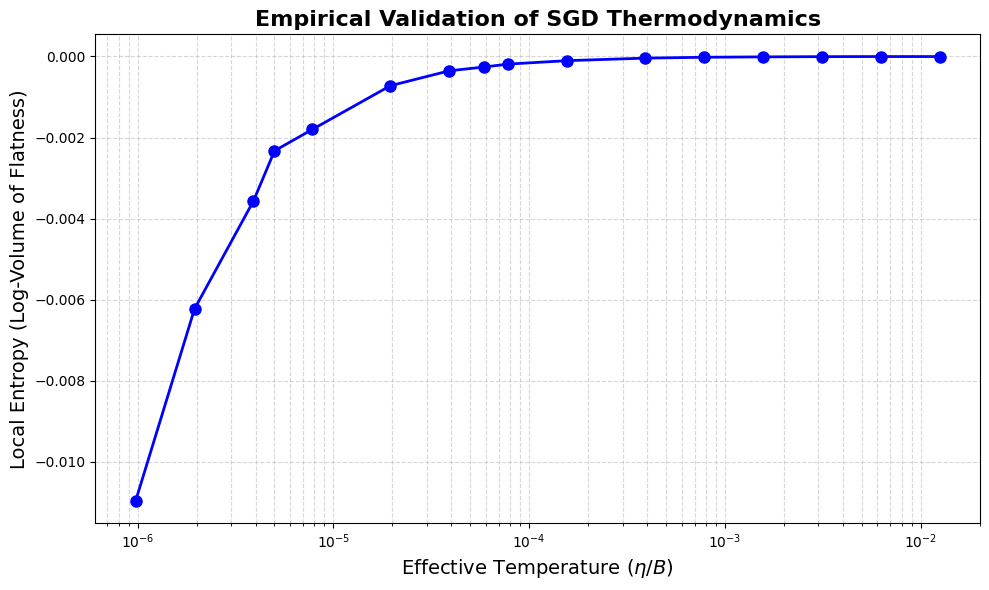

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import copy
import math

# --- 1. The Perturbation Function ---
def compute_local_entropy(base_model, dataloader, criterion, num_samples=100, perturbation_scale=0.03):
    """
    Approximates the Local Entropy by perturbing the weights and calculating logsumexp.
    """
    base_model.eval()
    losses = []
    
    # Extract the base weights into a flat vector (easier to perturb)
    base_weights = torch.nn.utils.parameters_to_vector(base_model.parameters())
    
    # We don't need gradients for this evaluation phase
    with torch.no_grad():
        for _ in range(num_samples):
            # 1. Generate Gaussian noise
            noise = torch.randn_like(base_weights) * perturbation_scale
            perturbed_weights = base_weights + noise
            
            # 2. Load the perturbed weights into a temporary model
            temp_model = copy.deepcopy(base_model)
            torch.nn.utils.vector_to_parameters(perturbed_weights, temp_model.parameters())
            
            # 3. Calculate the loss of this perturbed model over the whole dataset
            total_loss = 0
            for batch_X, batch_y in dataloader:
                outputs = temp_model(batch_X)
                total_loss += criterion(outputs, batch_y).item()
            
            avg_loss = total_loss / len(dataloader)
            losses.append(avg_loss)
            
    # 4. Compute Local Entropy using the numerically stable LogSumExp
    # Math: log( 1/N * sum(exp(-loss)) ) = logsumexp(-losses) - log(N)
    losses_tensor = torch.tensor(losses)
    local_entropy = torch.logsumexp(-losses_tensor, dim=0) - math.log(num_samples)
    
    return local_entropy.item()

# --- 2. The Evaluation Loop ---
print("Loading saved models...")
# (Assuming 'dataset' and 'WideFlatMLP' are defined from the previous script)
results_dict = torch.load("thermodynamic_sweep_results.pth")
dataloader = DataLoader(dataset, batch_size=256, shuffle=False) # Large batch for fast evaluation
criterion = nn.CrossEntropyLoss()

temperatures = []
entropies = []

print("Calculating Local Entropy for each temperature regime...")
for temp, state_dict in sorted(results_dict.items()):
    # Reconstruct the model
    model = FlatMLP(input_dim=100)
    model.load_state_dict(state_dict)
    
    # Calculate Local Entropy
    # We use 100 samples. If it's too slow on your laptop, drop it to 50.
    entropy = compute_local_entropy(model, dataloader, criterion, num_samples=100, perturbation_scale=0.03)
    
    temperatures.append(temp)
    entropies.append(entropy)
    print(f"T = {temp:.6f} | Local Entropy = {entropy:.4f}")

# --- 3. The Grand Finale: Plotting ---
plt.figure(figsize=(10, 6))

# We use a semi-log axis because temperatures span several orders of magnitude
plt.semilogx(temperatures, entropies, marker='o', linestyle='-', color='b', markersize=8, linewidth=2)

plt.title("Empirical Validation of SGD Thermodynamics", fontsize=16, fontweight='bold')
plt.xlabel(r"Effective Temperature $(\eta / B)$", fontsize=14)
plt.ylabel("Local Entropy (Log-Volume of Flatness)", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("Local_Entropy_vs_Temperature.png", dpi=300)
plt.show()

In [9]:
def compute_loss_at_radius(base_model, dataloader, criterion, radius, num_directions=10):
    """
    Computes the average loss exactly at a distance 'r' from the minimum.
    This acts as the empirical proxy for the Franz-Parisi distance profile.
    """
    base_model.eval()
    losses = []
    
    # Extract the base weights
    base_weights = torch.nn.utils.parameters_to_vector(base_model.parameters())
    
    with torch.no_grad():
        for _ in range(num_directions):
            # 1. Generate a random direction vector
            direction = torch.randn_like(base_weights)
            
            # 2. Normalize it to have a length exactly equal to 1
            direction = direction / torch.norm(direction)
            
            # 3. Multiply by the exact scalar radius 'r'
            step_vector = direction * radius
            perturbed_weights = base_weights + step_vector
            
            # 4. Load the perturbed weights and calculate loss
            temp_model = copy.deepcopy(base_model)
            torch.nn.utils.vector_to_parameters(perturbed_weights, temp_model.parameters())
            
            total_loss = 0
            for batch_X, batch_y in dataloader:
                outputs = temp_model(batch_X)
                total_loss += criterion(outputs, batch_y).item()
            
            avg_loss = total_loss / len(dataloader)
            losses.append(avg_loss)
            
    # 5. Simply average the losses (no logsumexp here!)
    return sum(losses) / len(losses)

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import copy

# Assuming 'dataset', 'dataloader', 'criterion', 'WideFlatMLP', 
# and 'compute_loss_at_radius' are already defined in your notebook.

print("Loading saved models...")
results_dict = torch.load("thermodynamic_sweep_results.pth")

# 1. Define the radii to sweep
radii = np.arange(0.0, 3.1, 0.2)  # From 0 to 3 in steps of 0.2

# Dictionary to store the list of losses for each temperature
all_losses = {}

# Sort temperatures from coldest to hottest
temperatures = sorted(list(results_dict.keys()))[2:]

print(f"Found {len(temperatures)} models. Computing loss landscapes...")

# 2. Evaluate every model across all radii
for temp in temperatures:
    print(f"\n--- Evaluating Model: T = {temp:.6f} ---")
    
    # Load the specific model
    model = FlatMLP(input_dim=100)
    model.load_state_dict(results_dict[temp])
    
    temp_losses = []
    for r in radii:
        # NOTE: If this takes too long on your machine, reduce num_directions to 10
        loss_r = compute_loss_at_radius(model, dataloader, criterion, radius=r, num_directions=20)
        temp_losses.append(loss_r)
        print(f"  Radius {r:.1f} -> Average Loss = {loss_r:.4f}")
        
    all_losses[temp] = temp_losses

# 3. Generate the Thesis-Ready Plot
plt.figure(figsize=(12, 8))

# Setup a colormap: Blue (Cold/Sharp) -> Red (Hot/Flat)
# We use a logarithmic norm because your temperatures span orders of magnitude
norm = plt.matplotlib.colors.LogNorm(vmin=min(temperatures), vmax=max(temperatures))
cmap = cm.get_cmap('coolwarm')

# Plot each line with its corresponding color from the colormap
for temp in temperatures:
    color = cmap(norm(temp))
    plt.plot(radii, all_losses[temp], marker='o', linestyle='-', color=color, 
             linewidth=2.5, alpha=0.8, label=f'T = {temp:.6f}')

# Professional formatting
plt.title("Evolution of Landscape Geometry with SGD Temperature", fontsize=16, fontweight='bold')
plt.xlabel("Perturbation Radius (r)", fontsize=14)
plt.ylabel("Average Expected Loss", fontsize=14)

# Create a beautiful legend
plt.legend(title="Effective Temp $(\eta/B)$", title_fontsize='13', fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Optional: You may want to restrict the Y-axis if the sharpest models explode too high,
# so that the flat models aren't squished at the bottom. Uncomment the line below if needed:
# plt.ylim(0, 5.0) 

plt.tight_layout()
plt.savefig("Full_Loss_vs_Radius_Evolution.png", dpi=300)
plt.show()

Loading saved models...
Found 14 models. Computing loss landscapes...

--- Evaluating Model: T = 0.000004 ---
  Radius 0.0 -> Average Loss = 0.0004
  Radius 0.2 -> Average Loss = 0.0004
  Radius 0.4 -> Average Loss = 0.0004
  Radius 0.6 -> Average Loss = 0.0004
  Radius 0.8 -> Average Loss = 0.0004
  Radius 1.0 -> Average Loss = 0.0004
  Radius 1.2 -> Average Loss = 0.0005
